In [1]:
import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import BackendSamplerV2

In [2]:
# Define the quantum registers and classical register
secret = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")
cr = ClassicalRegister(3, "c")

qc = QuantumCircuit(secret, Alice, Bob, cr)

In [3]:
# Create a random quantum state to teleport
np.random.seed(42)
theta = np.random.uniform(0.0, 1.0) * np.pi
varphi = np.random.uniform(0.0, 2.0) * np.pi

qc.u(theta, varphi, 0, secret)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

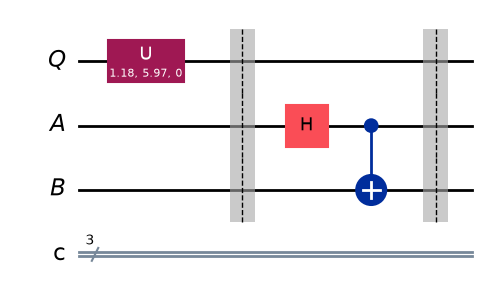

In [4]:
# Enatngle Alice and Bob's qubits
qc.h(Alice)
qc.cx(Alice, Bob)
qc.barrier()

qc.draw("mpl")

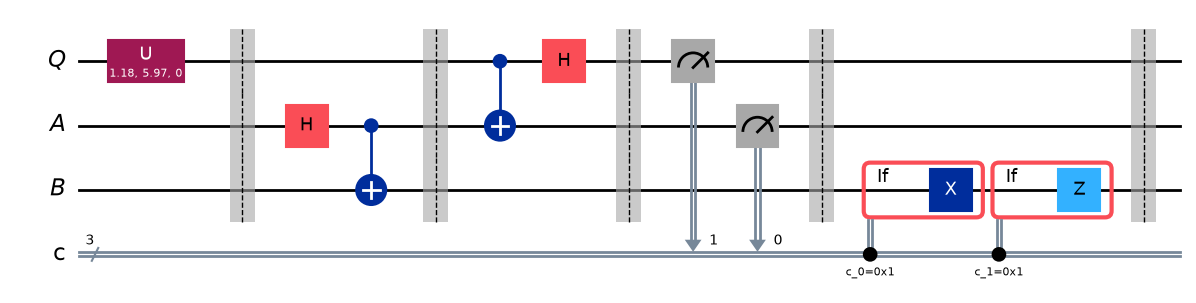

In [5]:
# Alice entangles her qubit with the secret qubit
qc.cx(secret, Alice)
qc.h(secret)
qc.barrier()

# Alice measures her qubits
qc.measure(secret, cr[1]) # Measure the secret qubit and store the result in the second classical bit
qc.measure(Alice, cr[0]) # Measure Alice's qubit and store the result in the first classical bit
qc.barrier()

# Bob applies the appropriate gates based on Alice's measurement results
with qc.if_test((cr[0], 1)):
    qc.x(Bob) # If Alice's measurement of the secret qubit is 1, apply X gate to Bob's qubit

with qc.if_test((cr[1], 1)):
    qc.z(Bob) # If Alice's measurement of her qubit is 1, apply Z gate to Bob's qubit
    
qc.barrier()
qc.draw("mpl")

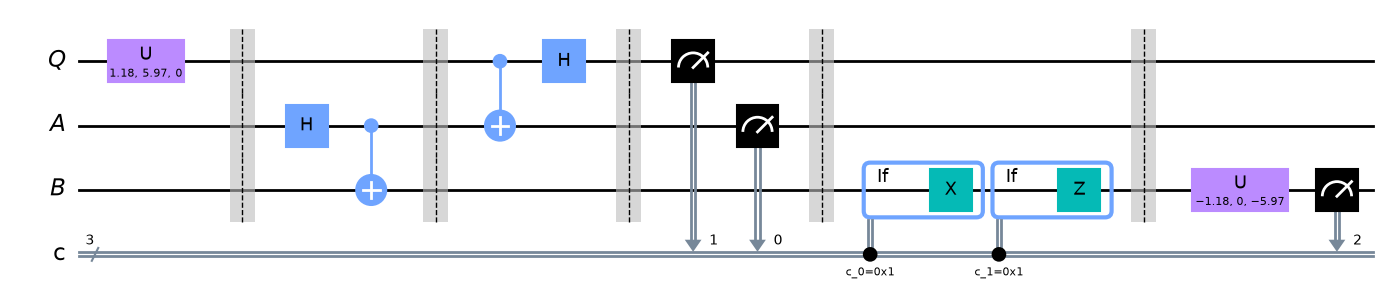

In [6]:
# Invert the unitary transformation to retrieve the original state
qc.u(theta, varphi, 0, Bob).inverse()

qc.measure(Bob, cr[2]) # Measure Bob's qubit and store the result in the third classical bit
qc.draw("mpl", style="clifford")

In [7]:
# Run the circuit on a simulator
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(target=backend.target, optimization_level=1)
qc_isa = pass_manager.run(qc)

# Run the circuit on the backend
sampler = BackendSamplerV2(backend=backend)
job = sampler.run([qc_isa], shots=5000)

res = job.result()
counts = res[0].data.c.get_counts()

print("Counts:", counts)

Counts: {'011': 1218, '000': 1258, '010': 1262, '001': 1262}


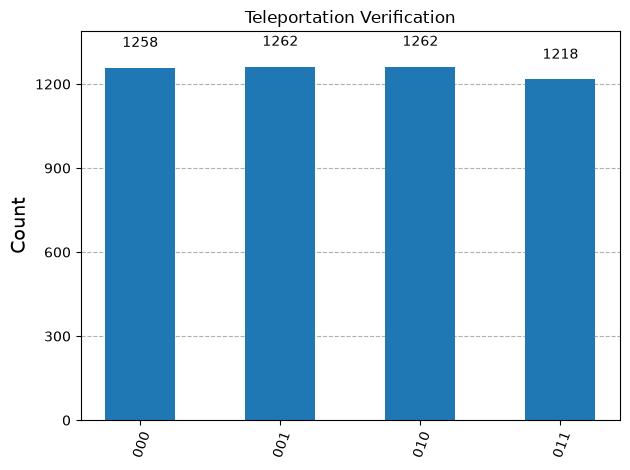

In [8]:
plot_histogram(counts, title="Teleportation Verification")

Noisy Counts: {'001': 1281, '010': 1190, '000': 1255, '011': 1204, '101': 11, '100': 19, '110': 21, '111': 19}


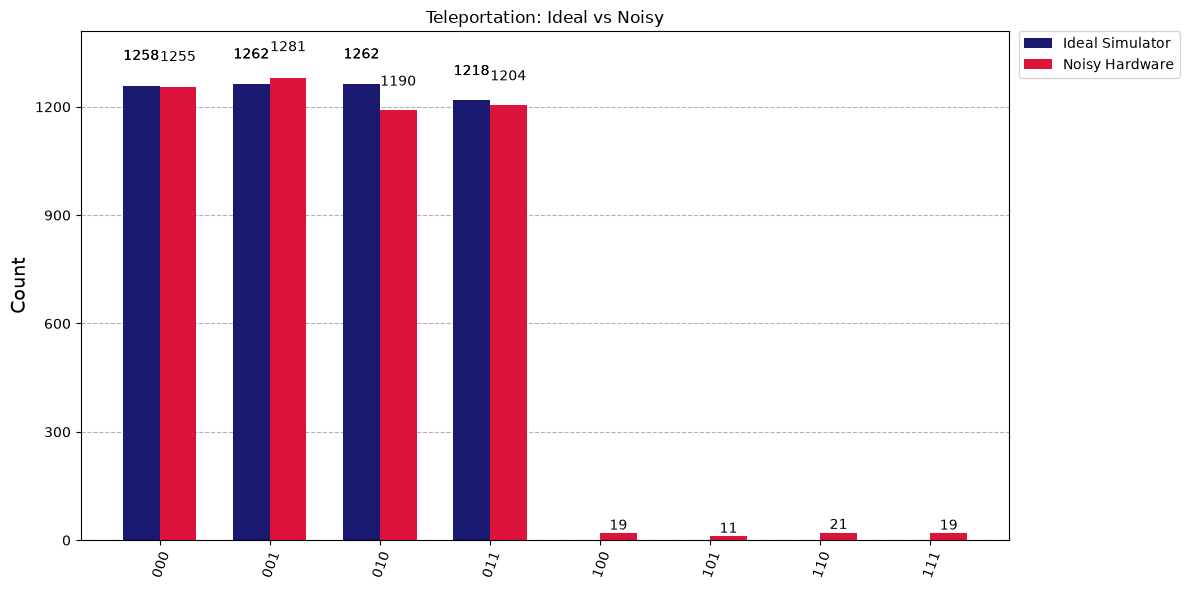

In [9]:
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2

# 1. Create the simulated noisy hardware profile
noisy_hardware_profile = GenericBackendV2(num_qubits=5, seed=42)

# 2. Extract ONLY the noise model, leaving the hardware's strict limitations behind
noise_model = NoiseModel.from_backend(noisy_hardware_profile)

# 3. Create a standard AerSimulator and inject the noise
noisy_simulator = AerSimulator(noise_model=noise_model)

# 4. Transpile the circuit for this specific simulator target
pass_manager_noisy = generate_preset_pass_manager(target=noisy_simulator.target, optimization_level=1)
qc_noisy = pass_manager_noisy.run(qc)

# 5. Execute using modern Qiskit V2 Primitives
sampler_noisy = BackendSamplerV2(backend=noisy_simulator)
job_noisy = sampler_noisy.run([qc_noisy], shots=5000)

# 6. Extract and visualize results
noisy_counts = job_noisy.result()[0].data.c.get_counts()

print("Noisy Counts:", noisy_counts)

# Plot both the ideal and noisy results side-by-side
plot_histogram(
    [counts, noisy_counts], 
    legend=["Ideal Simulator", "Noisy Hardware"], 
    title="Teleportation: Ideal vs Noisy", 
    color=["midnightblue", "crimson"],
    figsize=(12, 6)
)

In [10]:
from qiskit.quantum_info import partial_trace, Statevector
from qiskit.visualization import plot_bloch_multivector

# Rebuild the core circuit without measurements so we can extract the math cleanly
viz_qc = QuantumCircuit(secret, Alice, Bob)

# Initialization
viz_qc.u(theta, varphi, 0, secret)
state_stage_1 = Statevector(viz_qc)

# Entanglement & Alice's Ops
viz_qc.h(Alice)
viz_qc.cx(Alice, Bob)
viz_qc.cx(secret, Alice)
viz_qc.h(secret)
state_stage_2 = Statevector(viz_qc)

# Bob's Corrections
# Because we aren't measuring, we apply quantum-controlled gates instead of classical if_tests to complete the teleportation mathematically
viz_qc.cx(Alice, Bob)
viz_qc.cz(secret, Bob)
state_stage_3 = Statevector(viz_qc)

The Payload is generated on the Secret Qubit. Bob's qubit is at |0⟩.


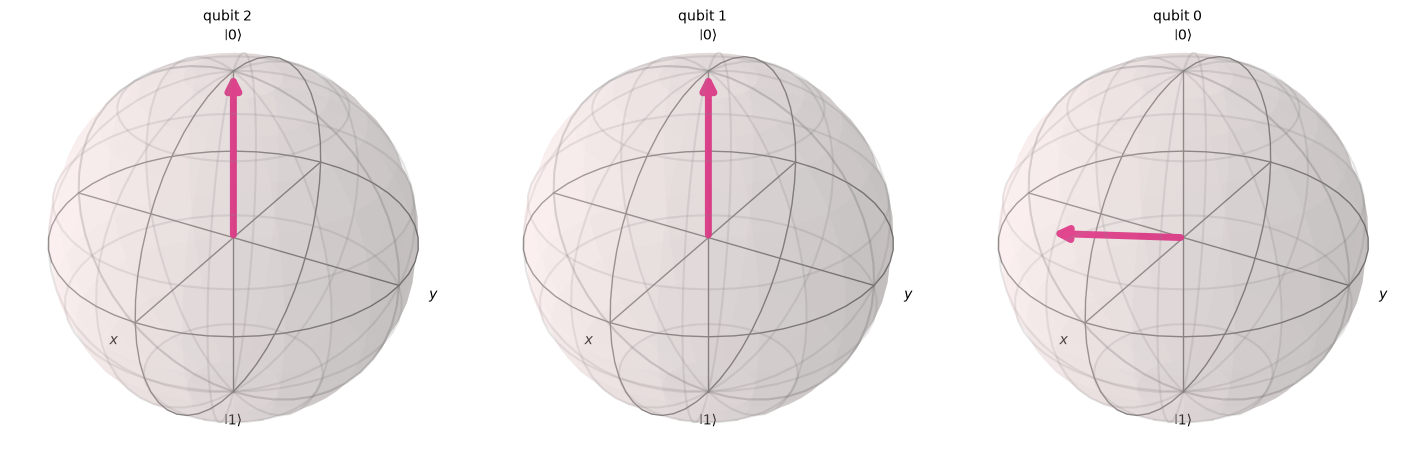

In [11]:
print("The Payload is generated on the Secret Qubit. Bob's qubit is at |0⟩.")
plot_bloch_multivector(state_stage_1, reverse_bits=True) 

Entanglement. The qubits are entangled. None of them have independent definitive states anymore.


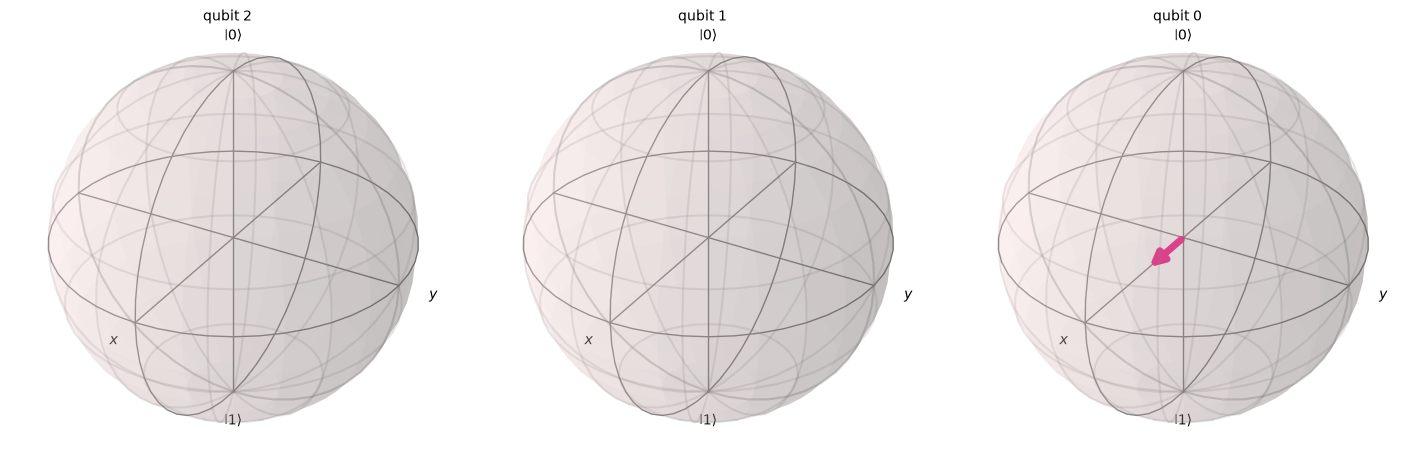

In [12]:
print("Entanglement. The qubits are entangled. None of them have independent definitive states anymore.")
plot_bloch_multivector(state_stage_2, reverse_bits=True)

Completion. Bob's qubit now perfectly matches the original Secret payload.
The Secret qubit is now pointing straight up at |0⟩ or |1⟩. The original state was destroyed, proving the No-Cloning Theorem!


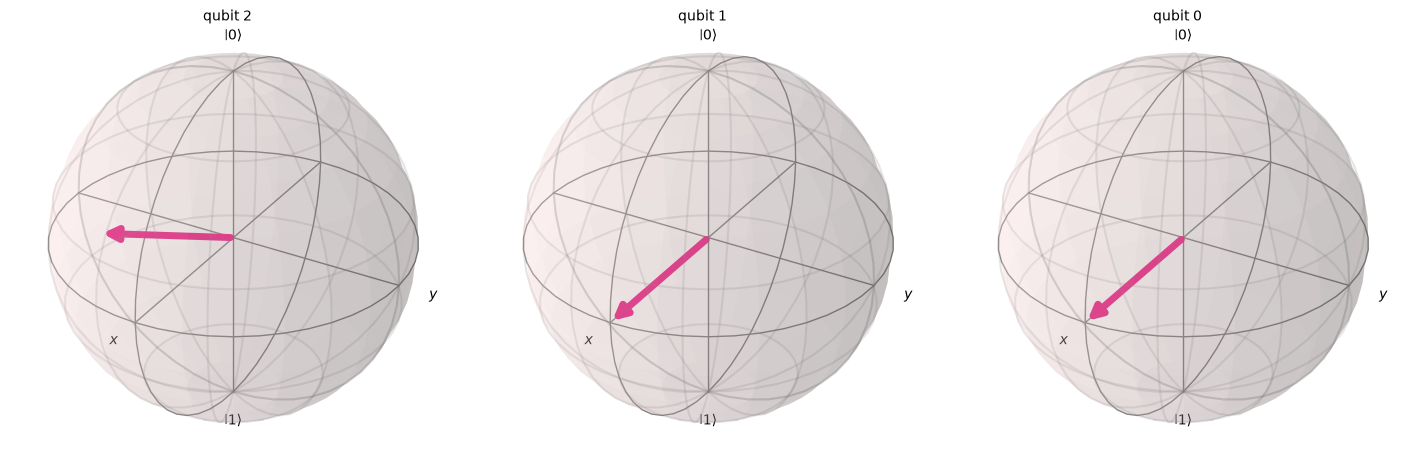

In [13]:
print("Completion. Bob's qubit now perfectly matches the original Secret payload.")
print("The Secret qubit is now pointing straight up at |0⟩ or |1⟩. The original state was destroyed, proving the No-Cloning Theorem!")
plot_bloch_multivector(state_stage_3, reverse_bits=True)